# TransFG: CUB-200-2011 세밀 분류 (Fine-grained Bird Recognition)

**논문**: TransFG: A Transformer Architecture for Fine-grained Recognition (AAAI 2022)

## 수정 사항 (원본 대비)

| 문제 | 원본 | 수정 |
|------|------|------|
| `scipy.misc.imread` | scipy 1.3+에서 제거됨 (ImportError) | PIL + numpy 로 교체 |
| `apex` FP16 | CUDA 전용 (MPS/CPU에서 ImportError) | 제거 → PyTorch native AMP (CUDA만) |
| 분산학습 코드 | `dist.barrier()` 등 | 단일 디바이스용으로 제거 |
| CUB 경로 | 하드코딩 `/opt/tiger/...` | 중첩 폴더 구조 자동 감지 |
| `pin_memory` | 항상 `True` | CUDA=`True`, MPS/CPU=`False` |
| `Image.BILINEAR` | torchvision 경고 | `InterpolationMode.BILINEAR` 로 교체 |

## MPS 호환성
모델 연산 (Conv2d, LayerNorm, matmul 등) 모두 MPS 지원 ✓  
단, ViT-B/16 + 448×448 학습은 무거우므로 **Ubuntu (CUDA) 이전을 권장**합니다.

In [1]:
# Cell 01: 환경 확인 (Python / PyTorch / 가속기 가용성)
import sys, torch, torchvision

print(f"Python       : {sys.version}")
print(f"PyTorch      : {torch.__version__}")
print(f"torchvision  : {torchvision.__version__}")
print(f"CUDA 가용    : {torch.cuda.is_available()}")
print(f"MPS  가용    : {torch.backends.mps.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 디바이스: {torch.cuda.get_device_name(0)}")
    print(f"CUDA 메모리  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Python       : 3.9.6 (default, Apr 30 2025, 02:07:17) 
[Clang 17.0.0 (clang-1700.0.13.5)]
PyTorch      : 2.8.0
torchvision  : 0.23.0
CUDA 가용    : False
MPS  가용    : True


In [2]:
# Cell 02: 프로젝트 경로 및 sys.path 설정 (PyCharm Jupyter 환경)
import os, sys

PROJECT_ROOT = '/Users/macminim4/Aiffel03/Project01/TransFG'
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"작업 디렉토리 : {os.getcwd()}")
print(f"sys.path[0]   : {sys.path[0]}")

작업 디렉토리 : /Users/macminim4/Aiffel03/Project01/TransFG
sys.path[0]   : /Users/macminim4/Aiffel03/Project01/TransFG


In [3]:
# Cell 03: 라이브러리 임포트
import logging
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.transforms import InterpolationMode

# 프로젝트 모듈
from project_config import (
    DEVICE, DATA_ROOT, PRETRAINED_DIR, OUTPUT_DIR, LOG_DIR,
    TRAIN_BATCH_SIZE, EVAL_BATCH_SIZE, NUM_WORKERS, PIN_MEMORY,
    NUM_CLASSES, MODEL_TYPE, IMG_SIZE, SPLIT,
    NUM_STEPS, WARMUP_STEPS, EVAL_EVERY, LR, SEED, make_args,
)
from train_utils import (
    setup_model, validate, train as train_model,
    set_seed, load_checkpoint, AverageMeter,
)
from utils.data_utils import get_loader

# 로깅 설정
logging.basicConfig(
    format='%(asctime)s | %(levelname)s | %(name)s - %(message)s',
    datefmt='%H:%M:%S',
    level=logging.INFO,
)
logger = logging.getLogger('TransFG')
print("임포트 완료")

임포트 완료


In [4]:
# Cell 04: 설정 확인
print("=" * 55)
print(f"  디바이스        : {DEVICE}")
print(f"  데이터 경로     : {DATA_ROOT}")
print(f"  사전학습 경로   : {PRETRAINED_DIR}")
print(f"  데이터 존재여부 : {os.path.isdir(DATA_ROOT)}")
print(f"  가중치 존재여부 : {os.path.isfile(PRETRAINED_DIR)}")
print(f"  배치(학습/평가) : {TRAIN_BATCH_SIZE} / {EVAL_BATCH_SIZE}")
print(f"  NUM_WORKERS     : {NUM_WORKERS}")
print(f"  PIN_MEMORY      : {PIN_MEMORY}")
print(f"  이미지 크기     : {IMG_SIZE}x{IMG_SIZE}")
print(f"  총 학습 스텝    : {NUM_STEPS}")
print("=" * 55)

  디바이스        : mps
  데이터 경로     : /Users/macminim4/Aiffel03/Project01/TransFG/CUB_200_2011
  사전학습 경로   : /Users/macminim4/Aiffel03/Project01/TransFG/pretrained/ViT-B_16.npz
  데이터 존재여부 : True
  가중치 존재여부 : True
  배치(학습/평가) : 8 / 4
  NUM_WORKERS     : 0
  PIN_MEMORY      : False
  이미지 크기     : 448x448
  총 학습 스텝    : 10000


In [5]:
# Cell 05: 디바이스 설정 및 시드 고정
set_seed(SEED, device_type=DEVICE.type)
print(f"시드 고정 완료 : seed={SEED}")
print(f"사용 디바이스  : {DEVICE}")

# args 객체 생성 (기존 utils 코드와 호환되는 Namespace)
args = make_args(
    name='transfg_cub200',
    num_steps=NUM_STEPS,   # 빠른 테스트: 200
    eval_every=EVAL_EVERY, # 빠른 테스트: 50
)
print(f"\nargs.data_root        : {args.data_root}")
print(f"args.train_batch_size : {args.train_batch_size}")
print(f"args.num_steps        : {args.num_steps}")
print(f"args.device           : {args.device}")

시드 고정 완료 : seed=42
사용 디바이스  : mps

args.data_root        : /Users/macminim4/Aiffel03/Project01/TransFG/CUB_200_2011
args.train_batch_size : 8
args.num_steps        : 10000
args.device           : mps


In [6]:
# Cell 06: 데이터 로더 생성
# 모든 이미지를 메모리에 올리므로 시간이 걸릴 수 있습니다
print("CUB-200-2011 데이터 로딩 중... (잠시 기다려 주세요)")
train_loader, test_loader = get_loader(args)

print(f"\n[학습]  배치 수: {len(train_loader):4d} | 샘플 수: {len(train_loader.dataset)}")
print(f"[테스트] 배치 수: {len(test_loader):4d} | 샘플 수: {len(test_loader.dataset)}")
print(f"배치 크기(학습): {args.train_batch_size}  /  배치 크기(평가): {args.eval_batch_size}")

CUB-200-2011 데이터 로딩 중... (잠시 기다려 주세요)

[학습]  배치 수:  749 | 샘플 수: 5994
[테스트] 배치 수: 1449 | 샘플 수: 5794
배치 크기(학습): 8  /  배치 크기(평가): 4


In [7]:
# Cell 07: 데이터 배치 형태 확인
sample_imgs, sample_labels = next(iter(train_loader))
print(f"이미지 텐서 형태 : {sample_imgs.shape}   (B, C, H, W)")
print(f"레이블 텐서 형태 : {sample_labels.shape}")
print(f"이미지 dtype     : {sample_imgs.dtype}")
print(f"레이블 범위      : {sample_labels.min().item()} ~ {sample_labels.max().item()}")
print(f"픽셀 범위(정규화): [{sample_imgs.min():.3f}, {sample_imgs.max():.3f}]")

이미지 텐서 형태 : torch.Size([8, 3, 448, 448])   (B, C, H, W)
레이블 텐서 형태 : torch.Size([8])
이미지 dtype     : torch.float32
레이블 범위      : 46 ~ 196
픽셀 범위(정규화): [-2.118, 2.640]


/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_66789/1193112286.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_66789/1193112286.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_66789/1193112286.py:16: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_66789/1193112286.py:16: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipykernel_66789/1193112286.py:16: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/9n/m_4b8hrx0nvgh_6f0yczjhbm0000gn/T/ipyke

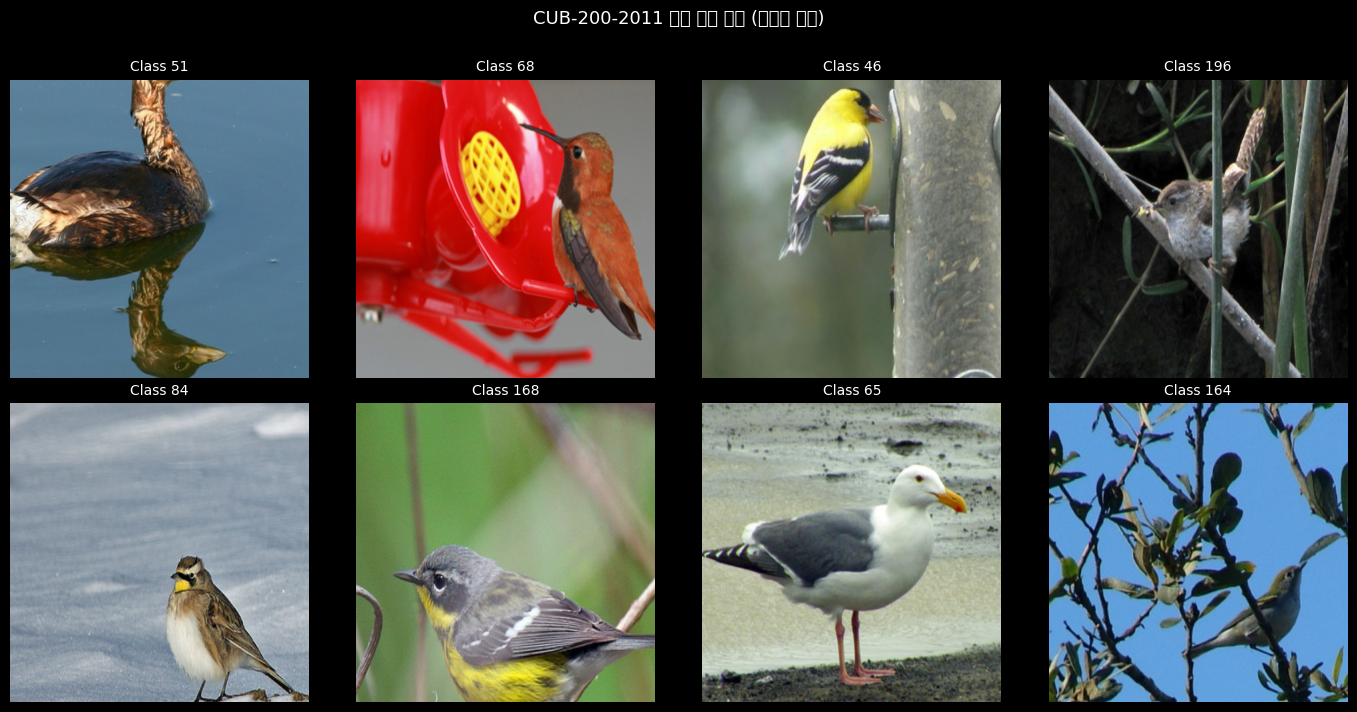

In [8]:
# Cell 08: 학습 샘플 이미지 시각화

def denormalize(tensor):
    """ImageNet 정규화 역변환"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img_np = denormalize(sample_imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f"Class {sample_labels[i].item()}", fontsize=10)
    ax.axis('off')
plt.suptitle("CUB-200-2011 학습 배치 샘플 (정규화 해제)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Cell 09: CUB-200-2011 클래스 이름 로드
classes_file = os.path.join(DATA_ROOT, 'classes.txt')
class_names = {}
with open(classes_file, 'r') as f:
    for line in f:
        idx_str, name = line.strip().split(' ', 1)
        class_names[int(idx_str) - 1] = name   # 0-indexed

print(f"총 클래스 수 : {len(class_names)}")
print("\n클래스 샘플 (25개 간격):")
for i in range(0, 200, 25):
    print(f"  [{i:3d}] {class_names[i]}")

총 클래스 수 : 200

클래스 샘플 (25개 간격):
  [  0] 001.Black_footed_Albatross
  [ 25] 026.Bronzed_Cowbird
  [ 50] 051.Horned_Grebe
  [ 75] 076.Dark_eyed_Junco
  [100] 101.White_Pelican
  [125] 126.Nelson_Sharp_tailed_Sparrow
  [150] 151.Black_capped_Vireo
  [175] 176.Prairie_Warbler


In [10]:
# Cell 10: 모델 초기화 및 Google 사전학습 가중치 로드 (ViT-B_16.npz)
print("모델 초기화 중...")
model = setup_model(args)
print(f"\n모델 타입  : {args.model_type}")
print(f"이미지 크기: {args.img_size}x{args.img_size}")
print(f"클래스 수  : {NUM_CLASSES}")
print(f"Split 방식 : {args.split}")
print(f"디바이스   : {next(model.parameters()).device}")

모델 초기화 중...


14:58:34 | INFO | models.modeling - load_pretrained: resized variant: torch.Size([1, 197, 768]) to torch.Size([1, 785, 768])


load_pretrained: grid-size from 14 to 28


14:58:34 | INFO | train_utils - 사전학습 가중치 로드 완료: /Users/macminim4/Aiffel03/Project01/TransFG/pretrained/ViT-B_16.npz
14:58:34 | INFO | train_utils - 총 학습 가능 파라미터: 86.4M



모델 타입  : ViT-B_16
이미지 크기: 448x448
클래스 수  : 200
Split 방식 : non-overlap
디바이스   : mps:0


In [11]:
# Cell 11: 모델 파라미터 수 확인
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"전체 파라미터     : {total_p:>12,}  ({total_p/1e6:.1f}M)")
print(f"학습 가능 파라미터: {trainable_p:>12,}  ({trainable_p/1e6:.1f}M)")

print("\n[Part Head / CLS Token / Norm 레이어]")
for name, param in model.named_parameters():
    if any(k in name for k in ('part_head', 'cls_token', 'part_norm')):
        print(f"  {name:<50s}: {list(param.shape)}")

전체 파라미터     :   86,404,040  (86.4M)
학습 가능 파라미터:   86,404,040  (86.4M)

[Part Head / CLS Token / Norm 레이어]
  transformer.embeddings.cls_token                  : [1, 1, 768]
  transformer.encoder.part_norm.weight              : [768]
  transformer.encoder.part_norm.bias                : [768]
  part_head.weight                                  : [200, 768]
  part_head.bias                                    : [200]


In [12]:
# Cell 12: 옵티마이저 및 스케줄러 설정 확인
from utils.scheduler import WarmupCosineSchedule

_opt = torch.optim.SGD(
    model.parameters(),
    lr=args.learning_rate, momentum=0.9, weight_decay=args.weight_decay,
)
_sch = WarmupCosineSchedule(_opt, warmup_steps=args.warmup_steps, t_total=args.num_steps)

print(f"옵티마이저   : SGD")
print(f"  lr         : {args.learning_rate}")
print(f"  momentum   : 0.9")
print(f"  weight_decay: {args.weight_decay}")
print(f"스케줄러     : WarmupCosine")
print(f"  warmup     : {args.warmup_steps} steps")
print(f"  total      : {args.num_steps} steps")
print(f"AMP (FP16)   : {DEVICE.type == 'cuda'}  (CUDA에서만 활성화)")
del _opt, _sch

옵티마이저   : SGD
  lr         : 0.03
  momentum   : 0.9
  weight_decay: 0.0
스케줄러     : WarmupCosine
  warmup     : 500 steps
  total      : 10000 steps
AMP (FP16)   : False  (CUDA에서만 활성화)


In [13]:
# Cell 13: 초기 검증 - 학습 전 사전학습 가중치 기반 성능
print("초기 검증 실행 중 (학습 전)...")
init_acc, init_loss = validate(model, test_loader, DEVICE)
print(f"\n초기 정확도 : {init_acc:.4f}  ({init_acc * 100:.2f}%)")
print(f"초기 손실   : {init_loss:.4f}")
print("(ImageNet-21k ViT-B_16 zero-shot 분류 성능)")

초기 검증 실행 중 (학습 전)...


Validation:   0%|          | 0/1449 [00:00<?, ?it/s]


초기 정확도 : 0.0040  (0.40%)
초기 손실   : 5.2959
(ImageNet-21k ViT-B_16 zero-shot 분류 성능)


In [ ]:
# Cell 14: 학습 실행
# ──────────────────────────────────────────────────────────────
# 빠른 테스트 (200 스텝) 원할 경우 아래 주석 해제:
# args = make_args(name='transfg_test', num_steps=200, eval_every=50)
# train_loader, test_loader = get_loader(args)
# ──────────────────────────────────────────────────────────────

print(f"학습 시작")
print(f"  디바이스   : {DEVICE}")
print(f"  총 스텝    : {args.num_steps}")
print(f"  AMP(FP16)  : {DEVICE.type == 'cuda'}")
if DEVICE.type == 'mps':
    print("  [참고] MPS는 CUDA 대비 느림. Ubuntu(CUDA) 이전 시 성능 향상 가능")
print("-" * 50)

best_accuracy = train_model(args, model, train_loader, test_loader)
print(f"\n최종 Best Accuracy: {best_accuracy:.4f}  ({best_accuracy * 100:.2f}%)")

15:05:39 | INFO | train_utils - ============================================================
15:05:39 | INFO | train_utils - 학습 시작
15:05:39 | INFO | train_utils -   device    : mps
15:05:39 | INFO | train_utils -   AMP(FP16) : False
15:05:39 | INFO | train_utils -   total steps: 10000
15:05:39 | INFO | train_utils - ============================================================


학습 시작
  디바이스   : mps
  총 스텝    : 10000
  AMP(FP16)  : False
  [참고] MPS는 CUDA 대비 느림. Ubuntu(CUDA) 이전 시 성능 향상 가능
--------------------------------------------------


Train 0/10000:   0%|          | 0/749 [00:00<?, ?it/s]

Validation:   0%|          | 0/1449 [00:00<?, ?it/s]

15:15:10 | INFO | train_utils - [Step   100/10000] loss=5.2865 | val_acc=0.0454 | val_loss=5.2375 | best=0.0000
15:15:11 | INFO | train_utils - 체크포인트 저장: /Users/macminim4/Aiffel03/Project01/TransFG/output/transfg_cub200_checkpoint.bin
15:15:11 | INFO | train_utils -   -> 최고 정확도 갱신: 0.0454 (저장 완료)


...

Validation:   0%|          | 0/1449 [00:00<?, ?it/s]

17:52:36 | INFO | train_utils - [Step  1700/10000] loss=0.4738 | val_acc=0.8530 | val_loss=0.5302 | best=0.8542


Validation:   0%|          | 0/1449 [00:00<?, ?it/s]

18:03:00 | INFO | train_utils - [Step  1800/10000] loss=0.4782 | val_acc=0.8611 | val_loss=0.4665 | best=0.8542
18:03:00 | INFO | train_utils - 체크포인트 저장: /Users/macminim4/Aiffel03/Project01/TransFG/output/transfg_cub200_checkpoint.bin
18:03:00 | INFO | train_utils -   -> 최고 정확도 갱신: 0.8611 (저장 완료)


Validation:   0%|          | 0/1449 [00:00<?, ?it/s]

In [ ]:
# Cell 15: TensorBoard 학습 곡선 시각화

# 방법 1: 이 노트북 안에서 인라인 실행
# %load_ext tensorboard
# %tensorboard --logdir logs

# 방법 2: 터미널에서 외부 실행
log_dir = os.path.join(PROJECT_ROOT, 'logs')
print("TensorBoard 실행 명령 (터미널):")
print(f"  cd {PROJECT_ROOT}")
print(f"  tensorboard --logdir logs")
print()
print("또는 이 노트북 셀에서 직접 실행:")
print("  %load_ext tensorboard")
print("  %tensorboard --logdir logs")

In [ ]:
# Cell 16: 저장된 최고 모델 체크포인트 불러오기
ckpt_path = os.path.join(OUTPUT_DIR, f"{args.name}_checkpoint.bin")

if os.path.isfile(ckpt_path):
    model = setup_model(args)           # 모델 구조 재생성
    model = load_checkpoint(ckpt_path, model, DEVICE)
    print(f"체크포인트 로드 완료: {ckpt_path}")
else:
    print(f"체크포인트 없음: {ckpt_path}")
    print("Cell 14 학습을 먼저 완료한 후 실행하세요.")

In [ ]:
# Cell 17: 최종 테스트셋 평가
print("최종 평가 실행 중...")
final_acc, final_loss = validate(model, test_loader, DEVICE)
print(f"\n최종 정확도 : {final_acc:.4f}  ({final_acc * 100:.2f}%)")
print(f"최종 손실   : {final_loss:.4f}")

In [ ]:
# Cell 18: 단일 이미지 추론 및 Top-5 시각화

infer_transform = transforms.Compose([
    transforms.Resize((600, 600), InterpolationMode.BILINEAR),
    transforms.CenterCrop((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def predict_topk(img_path: str, top_k: int = 5):
    """이미지 경로를 입력받아 Top-K 예측 반환 (클래스명, 확률)"""
    pil_img = Image.open(img_path).convert('RGB')
    x = infer_transform(pil_img).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=-1)[0]
    topk_probs, topk_idx = probs.topk(top_k)
    results = [(class_names[i.item()], p.item()) for i, p in zip(topk_idx, topk_probs)]
    return pil_img, results

# 테스트셋에서 첫 번째 샘플 이미지 경로 가져오기
sample_img_path = os.path.join(DATA_ROOT, 'images', test_loader.dataset.test_imgname[0])
true_label      = test_loader.dataset.test_label[0]

pil_img, top5 = predict_topk(sample_img_path)

# ── 시각화 ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.imshow(pil_img)
ax1.set_title(f"입력 이미지\n정답: {class_names[true_label]}", fontsize=11)
ax1.axis('off')

names_disp  = [r[0].split('.', 1)[-1].replace('_', ' ') for r in top5]
scores_disp = [r[1] * 100 for r in top5]
colors = ['tomato'] + ['steelblue'] * (len(top5) - 1)   # 1위는 빨강

bars = ax2.barh(names_disp[::-1], scores_disp[::-1], color=colors[::-1])
ax2.set_xlabel("확률 (%)")
ax2.set_title("Top-5 예측 결과", fontsize=12)
ax2.set_xlim(0, 105)
for bar, score in zip(bars, scores_disp[::-1]):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{score:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n[Top-5 예측]")
for rank, (name, prob) in enumerate(top5, 1):
    correct = " <-- 정답!" if class_names[true_label] == name else ""
    print(f"  Top-{rank}: {name:<50s} {prob * 100:5.1f}%{correct}")
print(f"\n정답 클래스: {class_names[true_label]}")